In [27]:
import os
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import regionmask
from pathlib import Path

# Paths
BASE_DIR = "/data0/hernanqd/plots_code/skagit_basin_de"
HUC8_GEO = os.path.join(BASE_DIR, "data/GIS/SkagitSubBasin_HUC8.geojson")
PRISM_FILE = "/data0/hernanqd/plots_code/skagit_basin_de/cumulative_precipitation_plot/exploring/prism_ppt_us_30s_20031017/prism_ppt_us_30s_20031017.tif"
VAULT_DIR = "/data0/skagit_met/data_transfer/data"

print("✓ Imports complete")

✓ Imports complete


In [28]:
# Load PRISM TIFF file for 2003-10-17
print("Loading PRISM TIFF data...")
with rasterio.open(PRISM_FILE) as src:
    prism_data = src.read(1)  # First band
    bounds = src.bounds
    crs = src.crs
    transform = src.transform
    
print(f"PRISM data shape: {prism_data.shape}")
print(f"PRISM bounds: {bounds}")
print(f"PRISM CRS: {crs}")
print(f"Data range: {np.nanmin(prism_data):.2f} to {np.nanmax(prism_data):.2f} mm")

Loading PRISM TIFF data...
PRISM data shape: (3105, 7025)
PRISM bounds: BoundingBox(left=-125.02083333333351, bottom=24.062500001034504, right=-66.47916666900852, top=49.9374999999995)
PRISM CRS: EPSG:4269
Data range: -9999.00 to 244.98 mm


In [29]:
# Load Skagit Basin geometry and create subbasin mask
print("Loading Skagit Basin HUC8 geometry...")
gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
print(f"Subbasins: {gdf['Name'].unique()}")
print(gdf[['Name', 'geometry']])

Loading Skagit Basin HUC8 geometry...
Subbasins: ['Upper Chehalis' 'Lower Chehalis' 'Grays Harbor' 'Willapa Bay' 'Duwamish'
 'Deschutes' 'Strait of Georgia' 'San Juan Islands' "Coeur d'Alene Lake"
 'Wenatchee' 'Upper Yakima' 'Naches' 'Upper Spokane' 'Rock'
 'Pend Oreille Lake' 'Priest' 'Hangman' 'Lower Columbia' 'Lower Spokane'
 'Little Spokane' 'Crescent-Hoko' 'Lower Snake-Tucannon' 'Palouse'
 'Lower Snake' 'Lake Washington' 'Puyallup' 'Skokomish' 'Hood Canal'
 'Puget Sound' 'Upper Skagit' 'Dungeness-Elwha' 'Nisqually' 'Lewis'
 'Upper Cowlitz' 'Lower Cowlitz' 'Lower Columbia-Sandy' 'Lower Willamette'
 'Clearwater' 'Lower Snake-Asotin' 'Colville' 'Sanpoil' 'Chief Joseph'
 'Methow' 'Lake Chelan' 'Upper Columbia-Entiat' 'Moses Coulee'
 'Upper Crab' 'Banks Lake' 'Lower Crab' 'Upper Columbia-Priest Rapids'
 'Lower Yakima' 'Franklin D. Roosevelt Lake' 'Kettle' 'Okanogan'
 'Similkameen' 'Pend Oreille' 'Middle Columbia-Lake Wallula' 'Walla Walla'
 'Klickitat' 'Hoh-Quillayute' 'Lower Columbia-

In [30]:
# Create mask from regionmask (same as in plot_specific_ar_events.py)
print("Creating subbasin mask...")

# Load a reference 4km PRISM file to get the coordinate system
prism_4km_path = os.path.join(VAULT_DIR, "PRISM/2001-2010/2003-01-01_2003-12-31_daily_4km_PRISM_data.zarr")
ds_ref = xr.open_zarr(prism_4km_path, consolidated=False)
lon_ref = ds_ref.lon.values
lat_ref = ds_ref.lat.values

# Create mask for subbasins
mask_3d = regionmask.mask_3D_geopandas(gdf, lon_ref, lat_ref)
region_indices = []
for r in ["Upper Skagit", "Sauk", "Lower Skagit"]:
    idx = gdf[gdf["Name"].str.contains(r, case=False)].index[0]
    region_indices.append(idx)
    print(f"  {r}: index {idx}")

mask_2d = mask_3d.sel(region=region_indices).any(dim='region')
ds_ref.close()

print(f"Mask shape: {mask_2d.shape}")
print(f"Masked area in 4km grid: {mask_2d.sum().values} cells")

Creating subbasin mask...
  Upper Skagit: index 29
  Sauk: index 65
  Lower Skagit: index 66
Mask shape: (33, 39)
Masked area in 4km grid: 571 cells


In [31]:
# Load full 2003 PRISM 4km data and calculate daily mean for each subbasin
print("Loading full year 2003 PRISM 4km data...")
prism_4km_path = os.path.join(VAULT_DIR, "PRISM/2001-2010/2003-01-01_2003-12-31_daily_4km_PRISM_data.zarr")
ds = xr.open_zarr(prism_4km_path, consolidated=False)
print(f"Dataset loaded: {len(ds.time)} days")

# Get the data
prism_vals = ds['ppt'].values  # shape: (time, lat, lon)
times = pd.to_datetime(ds.time.values)

# Calculate daily mean for each subbasin
daily_subbasin_means = {}
for r in ["Upper Skagit", "Sauk", "Lower Skagit"]:
    idx = gdf[gdf["Name"].str.contains(r, case=False)].index[0]
    region_mask = mask_3d.sel(region=idx).values
    
    # Apply mask to get values only in this subbasin
    means = []
    for day_data in prism_vals:
        masked_vals = day_data[region_mask > 0]
        if len(masked_vals) > 0:
            daily_mean = np.nanmean(masked_vals)
        else:
            daily_mean = np.nan
        means.append(daily_mean)
    
    daily_subbasin_means[r] = means
    print(f"  {r}: {np.nanmean(means):.2f} mm/day mean")

# Create a DataFrame
daily_precip_df = pd.DataFrame({
    'date': times,
    **daily_subbasin_means
})

print(f"\nDaily precipitation DataFrame shape: {daily_precip_df.shape}")
print(daily_precip_df.head(10))

Loading full year 2003 PRISM 4km data...
Dataset loaded: 360 days
  Upper Skagit: 5.99 mm/day mean
  Sauk: 7.12 mm/day mean
  Lower Skagit: 6.19 mm/day mean

Daily precipitation DataFrame shape: (360, 4)
        date  Upper Skagit       Sauk  Lower Skagit
0 2003-01-01     13.382225   9.435356      8.757924
1 2003-01-02     35.435982  40.820385     33.425602
2 2003-01-03     35.218674  32.706333     29.606775
3 2003-01-04     13.418113  11.529326      9.134424
4 2003-01-05     27.167414  28.326454     36.773376
5 2003-01-06      0.177105   2.143773      0.000000
6 2003-01-07      0.012147   0.000000      0.000000
7 2003-01-08      0.255899   0.000250      0.065455
8 2003-01-09      0.004758   0.000000      0.000000
9 2003-01-10      0.062366   0.000000      0.000000


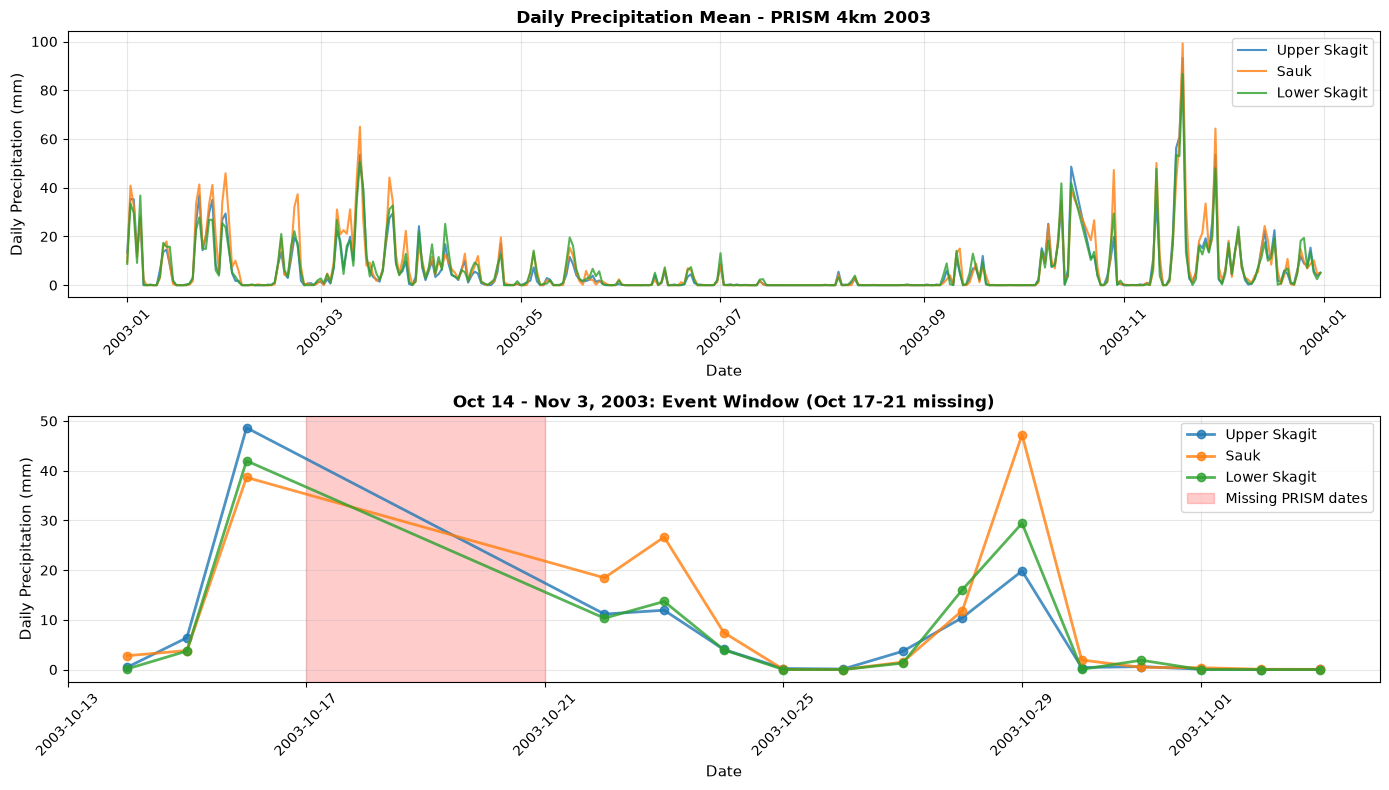

✓ Plot saved to: /data0/hernanqd/plots_code/daily_precip_subbasins_2003.png


In [32]:
# Plot daily precipitation for the three subbasins
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Daily precipitation time series
colors = {'Upper Skagit': '#1f77b4', 'Sauk': '#ff7f0e', 'Lower Skagit': '#2ca02c'}
for subbasin in ["Upper Skagit", "Sauk", "Lower Skagit"]:
    ax1.plot(daily_precip_df['date'], daily_precip_df[subbasin], 
            label=subbasin, linewidth=1.5, color=colors[subbasin], alpha=0.8)

ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Daily Precipitation (mm)', fontsize=11)
ax1.set_title('Daily Precipitation Mean - PRISM 4km 2003', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Highlight the October 17-21 gap (missing PRISM dates)
ax2_data = daily_precip_df[(daily_precip_df['date'] >= '2003-10-14') & 
                            (daily_precip_df['date'] <= '2003-11-03')].copy()

for subbasin in ["Upper Skagit", "Sauk", "Lower Skagit"]:
    ax2.plot(ax2_data['date'], ax2_data[subbasin], 
            label=subbasin, marker='o', linewidth=2, markersize=6, 
            color=colors[subbasin], alpha=0.8)

# Highlight missing dates
missing_dates = pd.to_datetime(['2003-10-17', '2003-10-18', '2003-10-19', '2003-10-20', '2003-10-21'])
ax2.axvspan(missing_dates[0], missing_dates[-1], alpha=0.2, color='red', label='Missing PRISM dates')

ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Daily Precipitation (mm)', fontsize=11)
ax2.set_title('Oct 14 - Nov 3, 2003: Event Window (Oct 17-21 missing)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/data0/hernanqd/plots_code/daily_precip_subbasins_2003.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to: /data0/hernanqd/plots_code/daily_precip_subbasins_2003.png")

KeyboardInterrupt: 

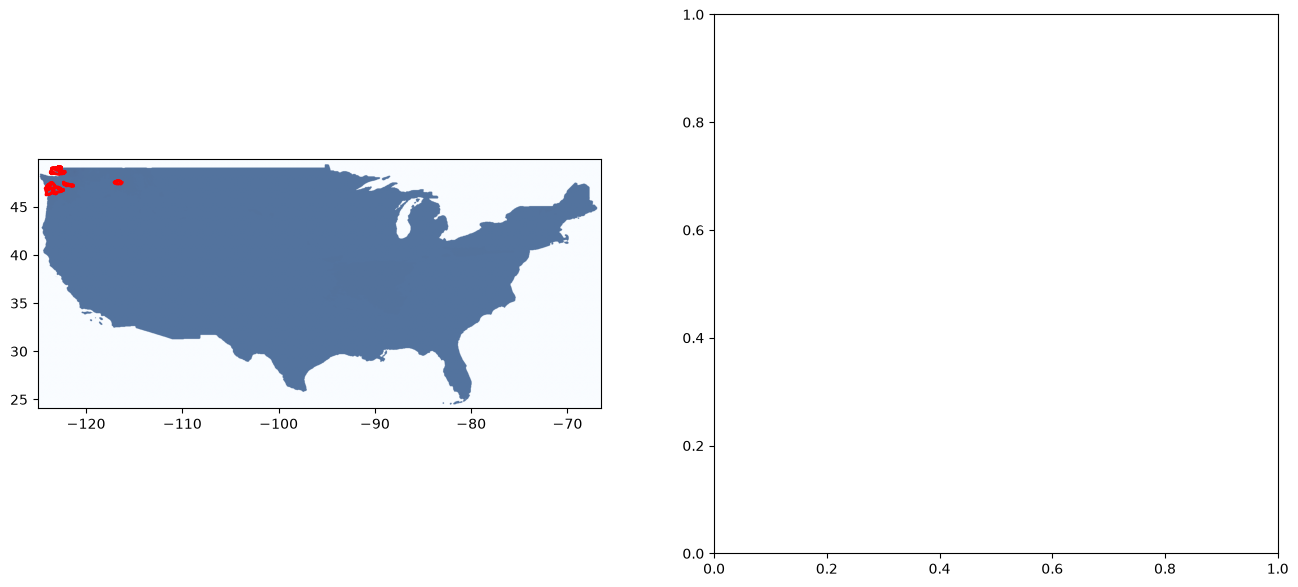

In [33]:
# Plot PRISM data with subbasin boundaries
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: PRISM 30-second resolution
ax = axes[0]
# Reproject PRISM TIFF bounds to proper extent
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
im1 = ax.imshow(prism_data, extent=extent, origin='upper', cmap='Blues', alpha=0.7)

# Overlay subbasin boundaries
for idx, row in gdf.iterrows():
    gpd.GeoSeries([row.geometry]).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)
    
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('PRISM 30s Resolution (2003-10-17)\nwith Subbasin Boundaries', fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=ax, label='Precipitation (mm)')
ax.grid(True, alpha=0.3)

# Plot 2: 4km mask from plot_specific_ar_events.py
ax = axes[1]
im2 = ax.imshow(mask_2d.values, extent=[lon_ref.min(), lon_ref.max(), lat_ref.min(), lat_ref.max()],
                origin='lower', cmap='RdYlGn', alpha=0.6, vmin=0, vmax=1)

# Overlay subbasin boundaries
for idx, row in gdf.iterrows():
    gpd.GeoSeries([row.geometry]).plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('4km Subbasin Mask\n(Upper Skagit + Sauk + Lower Skagit)', fontsize=12, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=ax, label='In Mask')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/data0/hernanqd/plots_code/prism_subbasins_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved")